# 📓 Notebook 01 – Dataset Preparation & Architecture Design
**Version 1 | Road Damage Detection**

This notebook covers:
1. Dataset overview (RDD2022)
2. Downloading and organizing the dataset
3. Exploratory Data Analysis (EDA)
4. Architecture design for all 3 models
5. Preprocessing pipeline explanation

## 1. Install Dependencies

In [10]:
# Run once to install all required packages
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', '../requirements.txt', '-q'])
print('✓ Dependencies installed')

✓ Dependencies installed


## 2. Dataset Overview – RDD2022

We use the **Road Damage Dataset 2022 (RDD2022)**, the largest publicly available road damage dataset.

| Property | Value |
|----------|-------|
| Total images | ~17,000 |
| Countries | Japan, India, Czech Republic, Norway, United States |
| Annotation format | Pascal VOC XML (bounding boxes) |
| Classes | D00, D10, D20, D40 |

### Damage Classes
| Code | Name | Description |
|------|------|-------------|
| D00 | Longitudinal Crack | Cracks parallel to traffic direction |
| D10 | Transverse Crack | Cracks perpendicular to traffic direction |
| D20 | Alligator Crack | Interconnected cracks forming a mesh pattern |
| D40 | Pothole | Surface depressions / holes |

## 3. Download Dataset

We use the **Japan + India subset** (~18,000 images) which is well-balanced and publicly available.

> **Option A (Recommended):** Download from the official Crowdworks challenge page  
> **Option B:** Use the Kaggle version (requires Kaggle API key)  
> **Option C:** Use the small demo subset provided below (for quick testing)

In [11]:
import sys
import random
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Add src to path
sys.path.insert(0, str(Path('..') / 'src'))

# ── Paths ─────────────────────────────────────────────────────────────────
ZIP_PATH  = Path('../data/RDD2022_India.zip')   # your real dataset zip
DATA_ROOT = Path('../data/prepared')            # extracted crops go here
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Zip  : {ZIP_PATH.resolve()}  exists={ZIP_PATH.exists()}')
print(f'Data : {DATA_ROOT.resolve()}')

Zip  : C:\Users\Srusti\Downloads\eclipse-java-2024-09-R-win32-x86_64\project\v1\data\RDD2022_India.zip  exists=True
Data : C:\Users\Srusti\Downloads\eclipse-java-2024-09-R-win32-x86_64\project\v1\data\prepared


In [12]:
from dataset import extract_and_prepare

# Check if already extracted to avoid re-running
already_done = any((DATA_ROOT / 'train' / c).exists() and
                   len(list((DATA_ROOT / 'train' / c).glob('*.jpg'))) > 0
                   for c in ['D00', 'D10', 'D20', 'D40'])

if already_done:
    print('✓ Dataset already prepared. Skipping extraction.')
else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f'Zip not found: {ZIP_PATH.resolve()}')
    extract_and_prepare(
        zip_path     = str(ZIP_PATH),
        output_root  = str(DATA_ROOT),
        val_split    = 0.15,
        normal_per_class = 400,
        seed         = 42,
    )

Opening zip...
Parsing 7706 XML annotations...
  Damage crops   : 8117
  Normal images  : 3921
Saving crops to disk...

✓ Dataset prepared. Class distribution:

── TRAIN ──
  D00 (Longitudinal Crack): 1473 images
  D10 (Transverse Crack): 94 images
  D20 (Alligator Crack): 1704 images
  D40 (Pothole): 3633 images
  Normal (Normal Road): 336 images
  Total: 7240

── VAL ──
  D00 (Longitudinal Crack): 261 images
  D10 (Transverse Crack): 19 images
  D20 (Alligator Crack): 317 images
  D40 (Pothole): 616 images
  Normal (Normal Road): 64 images
  Total: 1277


## 4. Exploratory Data Analysis (EDA)

In [13]:
from dataset import CLASS_NAMES, CLASS_TO_IDX, dataset_stats

CLASS_CODES = list(CLASS_TO_IDX.keys())
dataset_stats(str(DATA_ROOT))


── TRAIN ──
  D00 (Longitudinal Crack): 1473 images
  D10 (Transverse Crack): 94 images
  D20 (Alligator Crack): 1704 images
  D40 (Pothole): 3633 images
  Normal (Normal Road): 336 images
  Total: 7240

── VAL ──
  D00 (Longitudinal Crack): 261 images
  D10 (Transverse Crack): 19 images
  D20 (Alligator Crack): 317 images
  D40 (Pothole): 616 images
  Normal (Normal Road): 64 images
  Total: 1277


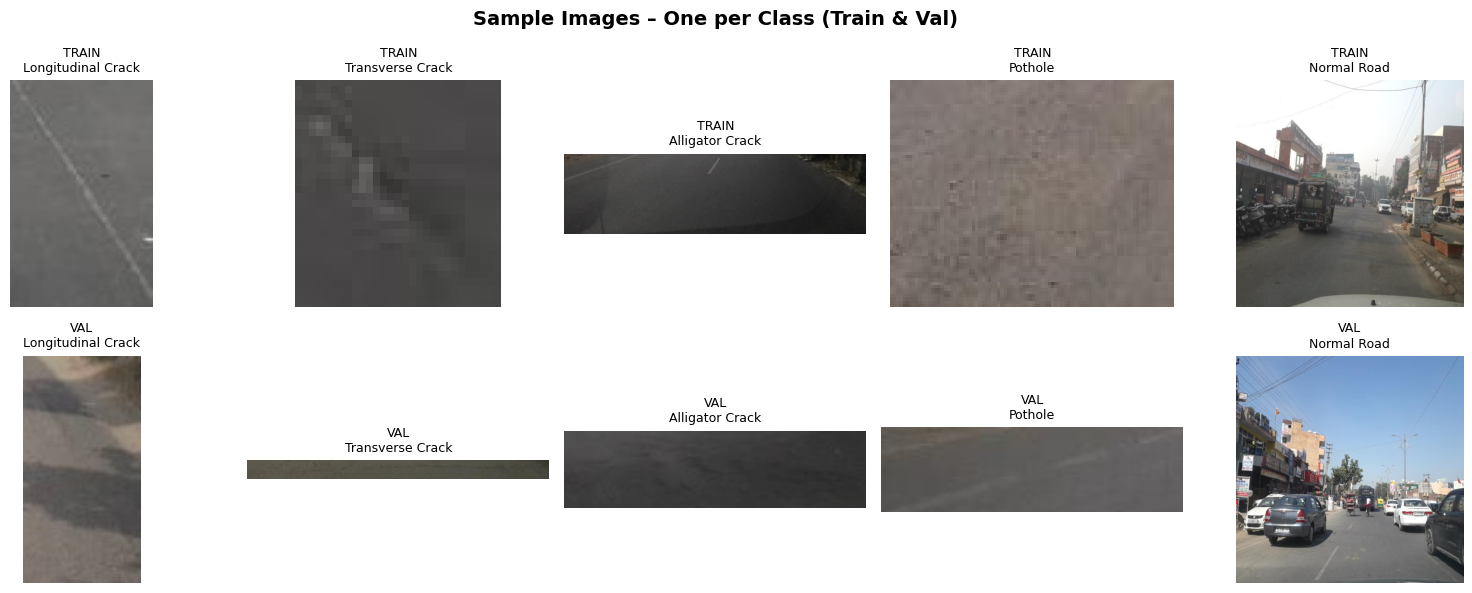

✓ Sample images saved


In [15]:
# Visualize sample images from each class (5 classes x 2 splits)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Sample Images – One per Class (Train & Val)', fontsize=14, fontweight='bold')

for col, code in enumerate(CLASS_CODES):
    for row, split in enumerate(['train', 'val']):
        folder = DATA_ROOT / split / code
        img_files = list(folder.glob('*.jpg'))
        if img_files:
            img = Image.open(random.choice(img_files)).convert('RGB')
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{split.upper()}\n{CLASS_NAMES[code]}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sample images saved')

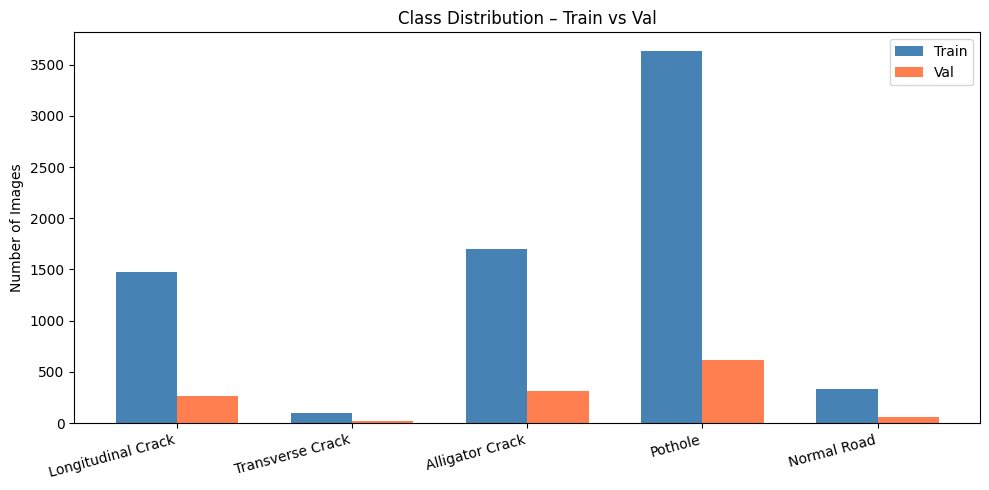

In [16]:
# Class distribution bar chart
train_counts = [len(list((DATA_ROOT / 'train' / c).glob('*.jpg'))) for c in CLASS_CODES]
val_counts   = [len(list((DATA_ROOT / 'val'   / c).glob('*.jpg'))) for c in CLASS_CODES]

x = np.arange(len(CLASS_CODES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts,   width, label='Val',   color='coral')
ax.set_xticks(x)
ax.set_xticklabels([CLASS_NAMES[c] for c in CLASS_CODES], rotation=15, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution – Train vs Val')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/class_distribution.png', dpi=150)
plt.show()

## 5. Preprocessing Pipeline

All images go through the following pipeline before being fed to the models:

```
Raw Image (any size)
    ↓
Resize to 224×224
    ↓
Data Augmentation (train only)
  • RandomHorizontalFlip
  • RandomVerticalFlip
  • ColorJitter (brightness, contrast, saturation)
    ↓
ToTensor  (HxWxC → CxHxW, scale to [0,1])
    ↓
Normalize (ImageNet mean/std)
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]
    ↓
Model Input Tensor: (B, 3, 224, 224)
```

**Why ImageNet normalization?**  
MobileNetV2 is pretrained on ImageNet. Using the same normalization ensures the pretrained weights work correctly.

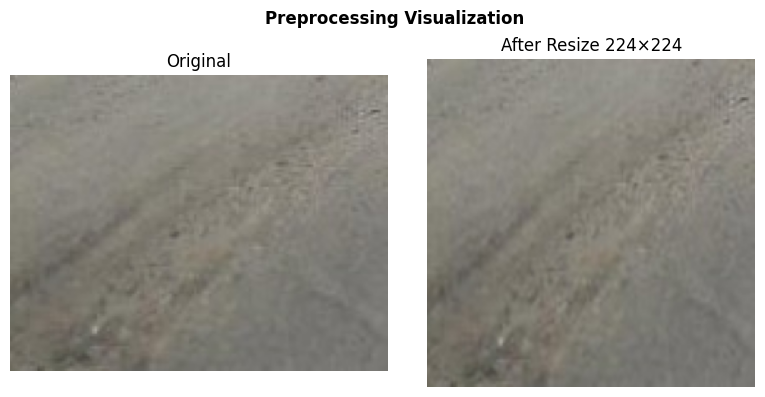

In [17]:
# Visualize the preprocessing pipeline on one image
from dataset import get_transforms
import torchvision.transforms.functional as TF

sample_path = list((DATA_ROOT / 'train' / 'D40').glob('*.jpg'))[0]
raw_img = Image.open(sample_path).convert('RGB')

# Apply transforms (without normalization for visualization)
vis_transform = plt.cm.get_cmap  # just for display
resized = raw_img.resize((224, 224))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_img);   axes[0].set_title('Original');        axes[0].axis('off')
axes[1].imshow(resized);   axes[1].set_title('After Resize 224×224'); axes[1].axis('off')
plt.suptitle('Preprocessing Visualization', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Architecture Design

### Model 1: YOLOv8n (Detection)
```
Input: 640×640 image
  ↓
CSPDarknet Backbone (feature extraction)
  ↓
PANet Neck (multi-scale feature fusion)
  ↓
Detection Head (3 scales: 80×80, 40×40, 20×20)
  ↓
Output: Bounding boxes + class labels + confidence
```
- Pretrained on COCO, fine-tuned on RDD2022
- Detects damage location AND type simultaneously

---

### Model 2: MobileNetV2 (Classification)
```
Input: 224×224 image
  ↓
MobileNetV2 Backbone (frozen, pretrained ImageNet)
  19 Inverted Residual Blocks
  ↓
Custom Head:
  Dropout(0.3) → Linear(1280→256) → ReLU → Dropout(0.2) → Linear(256→4)
  ↓
Output: 4-class probabilities
```
- Transfer learning: only head is trained
- Fast and lightweight

---

### Model 3: Custom CNN (Classification)
```
Input: 224×224 image
  ↓
Block 1: Conv(3→32)   + BN + ReLU + MaxPool → 112×112
Block 2: Conv(32→64)  + BN + ReLU + MaxPool → 56×56
Block 3: Conv(64→128) + BN + ReLU + MaxPool → 28×28
Block 4: Conv(128→256)+ BN + ReLU + MaxPool → 14×14
AdaptiveAvgPool → 4×4
  ↓
Flatten → Linear(4096→512) → ReLU → Dropout(0.4) → Linear(512→4)
  ↓
Output: 4-class probabilities
```
- Trained from scratch on RDD2022
- Demonstrates domain-specific learning

In [18]:
# Verify model architectures load correctly
import torch
from models import get_model, count_parameters

for name in ['mobilenetv2', 'customcnn']:
    model = get_model(name)
    params = count_parameters(model)
    dummy = torch.randn(2, 3, 224, 224)
    out = model(dummy)
    print(f'{name:15s} | Trainable params: {params:,} | Output shape: {out.shape}')

mobilenetv2     | Trainable params: 329,221 | Output shape: torch.Size([2, 5])
customcnn       | Trainable params: 2,489,125 | Output shape: torch.Size([2, 5])


In [19]:
# Verify DataLoader works
from dataset import get_dataloaders

train_loader, val_loader = get_dataloaders(str(DATA_ROOT), batch_size=16)
images, labels = next(iter(train_loader))
print(f'Batch shape : {images.shape}')   # (16, 3, 224, 224)
print(f'Labels shape: {labels.shape}')   # (16,)
print(f'Label values: {labels.tolist()}')

Train samples : 7240
Val   samples : 1277
Batch shape : torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label values: [2, 2, 2, 0, 3, 3, 3, 0, 3, 4, 0, 3, 3, 2, 2, 3]


## ✅ Summary

| Step | Status |
|------|--------|
| Dataset prepared | ✓ |
| EDA completed | ✓ |
| Preprocessing pipeline defined | ✓ |
| Model architectures verified | ✓ |
| DataLoaders working | ✓ |

**Next:** Open `02_model_implementation.ipynb` to build and inspect each model in detail.